IMPORTING THE NECESSARY LIBRARIES NEEDED

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA EXPLORATION


In [25]:
data = pd.read_csv('netflix_data.csv')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [26]:
data.describe(include='all')


(6234, 12)

HANDLING MISSING VALUES

In [29]:
print(data.isnull().sum())


show_id            0
type               0
title              0
director        1958
cast             569
country          474
date_added         0
release_year       0
rating             9
duration           0
listed_in          0
description        0
dtype: int64


In [59]:

data['rating'] = data['rating'].fillna(data['rating'].mode()[0])
data = data.dropna(subset=['date_added'])    # only a handful of rows
data = data.drop_duplicates()

In [60]:
print(data.isnull().sum())

show_id            0
type               0
title              0
director        1958
cast             569
country          474
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64


DATA EXPLORATION

In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6223 entries, 0 to 6222
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6223 non-null   int64
 1   type          6223 non-null   str  
 2   title         6223 non-null   str  
 3   director      6223 non-null   str  
 4   cast          6223 non-null   str  
 5   country       6223 non-null   str  
 6   date_added    6223 non-null   str  
 7   release_year  6223 non-null   int64
 8   rating        6223 non-null   str  
 9   duration      6223 non-null   str  
 10  listed_in     6223 non-null   str  
 11  description   6223 non-null   str  
dtypes: int64(2), str(10)
memory usage: 583.5 KB


In [35]:
data['release_year'].describe()


count    6223.000000
mean     2013.362205
std         8.816695
min      1925.000000
25%      2013.000000
50%      2016.000000
75%      2018.000000
max      2020.000000
Name: release_year, dtype: float64

In [36]:
data['release_year'].skew()


np.float64(-3.7053420926476077)

In [37]:
data['type'].value_counts(normalize=True)


type
Movie      0.6852
TV Show    0.3148
Name: proportion, dtype: float64

In [38]:
data['rating'].value_counts()


rating
TV-MA       2034
TV-14       1695
TV-PG        699
R            508
PG-13        286
NR           217
PG           184
TV-Y7        168
TV-G         149
TV-Y         142
TV-Y7-FV      95
G             37
UR             7
NC-17          2
Name: count, dtype: int64

In [39]:
data['country'].value_counts().head(10)

country
United States     2026
India              777
Unknown            474
United Kingdom     347
Japan              175
Canada             141
South Korea        136
Spain              117
France              90
Mexico              83
Name: count, dtype: int64

Data Visualization

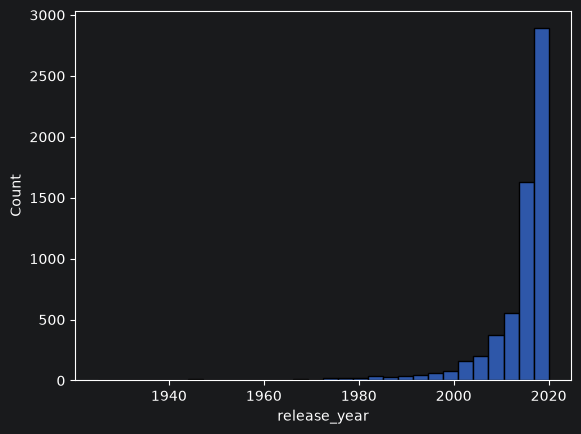

In [40]:
sns.histplot(data['release_year'], bins=30)
plt.show()

In [41]:
print(data['release_year'].mean())
print(data['release_year'].median())

2013.3622047244094
2016.0


In [42]:
print((data['release_year'] >= 2015).mean())

0.6800578499116182


In [43]:
#"release_year is strongly left-skewed (skewness -3.71). The mean (2013.4) is lower than the median (2016), because a small number of older titles pull the average down. The median is therefore the better measure of central tendency: half of all titles were released in 2016 or later."

In [45]:
data.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...
5,80163890,TV Show,Apaches,Unknown,"Alberto Ammann, Eloy Azorín, Verónica Echegui,...",Spain,"September 8, 2017",2016,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanis...",A young journalist is forced into a life of cr...
6,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f..."
7,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,"September 8, 2017",2017,TV-MA,60 min,Stand-Up Comedy,Fabrizio Copano takes audience participation t...
8,80117902,TV Show,Fire Chasers,Unknown,Unknown,United States,"September 8, 2017",2017,TV-MA,1 Season,"Docuseries, Science & Nature TV","As California's 2016 fire season rages, brave ..."
9,70304990,Movie,Good People,Henrik Ruben Genz,"James Franco, Kate Hudson, Tom Wilkinson, Omar...","United States, United Kingdom, Denmark, Sweden","September 8, 2017",2014,R,90 min,"Action & Adventure, Thrillers",A struggling couple can't believe their luck w...


Most watched genres. listed_in holds several genres in one cell (e.g. "Dramas, International Movies"), so split them first. The dataset has no viewing figures, so "most watched" here means the most titles per genre.

C:\Users\Moses\AppData\Local\Temp\ipykernel_30660\516119074.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')


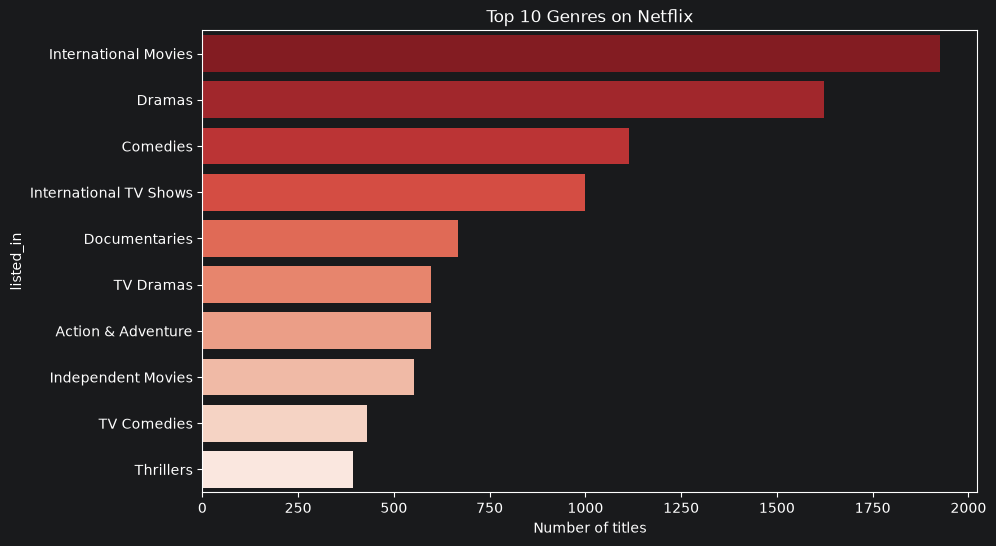

In [62]:
genres = data['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of titles')
plt.savefig('images/top_genres.png', dpi=300, bbox_inches='tight')
plt.show()

RATING DISTRIBUTION

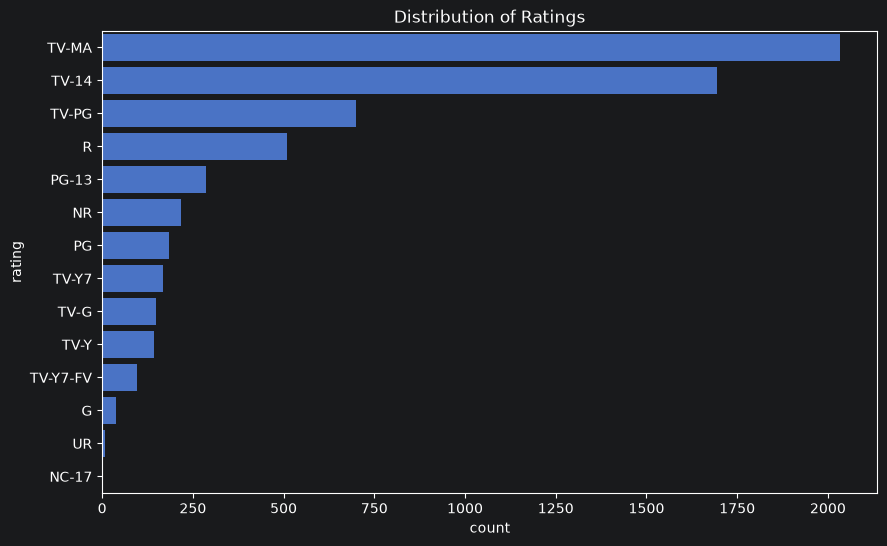

In [64]:
plt.figure(figsize=(10, 6))
sns.countplot(y='rating', data=data, order=data['rating'].value_counts().index)
plt.title('Distribution of Ratings')
plt.savefig('images/ratings_python.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
data.to_csv('netflix_clean.csv', index=False)

show_id            0
type               0
title              0
director        1958
cast             569
country          474
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64
